### Pretrained Monet2Photo CycleGAN & Image Generation

##### Setting up environment & loading model + data

To begin the initial setup for the pretrained CycleGAN, we first clone the repository and install the required libraries.

In [1]:
# Clone the repository and nanvigate into the directory
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

c:\Users\Yoshio\OneDrive\Bildung\Master (CBS)\Semester-03\Advanced ML for CV\final_project\Advanced-Machine-Learning-for-Computer-Vision\pytorch-CycleGAN-and-pix2pix


Cloning into 'pytorch-CycleGAN-and-pix2pix'...


In [4]:
# Install needed packages
!pip install torch torchvision torchaudio
!pip install dominate visdom wandb
!pip install kagglehub

  Using cached kagglehub-0.3.13-py3-none-any.whl.metadata (38 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached kagglehub-0.3.13-py3-none-any.whl (68 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


Next, the checkpoints for the model must be downloaded.

In [10]:
!pip install scikit-image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 18.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]


In [1]:
from glob import glob

import numpy as np
from skimage.io import imread
from skimage.metrics import structural_similarity


In [2]:
import urllib.request
import zipfile
import os


In [2]:
# Create directory
os.makedirs("checkpoints/monet2photo_pretrained", exist_ok=True)

# Download pretrained model
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/monet2photo.pth",
    "checkpoints/monet2photo_pretrained/latest_net_G.pth"
)

('checkpoints/monet2photo_pretrained/latest_net_G.pth',
 <http.client.HTTPMessage at 0x2033df85310>)

Then, the datasets Monet2Photo and Cezanne2Photo are downloaded. Each dataset is saved into a dedicated folder, extracted, and the original zip file is removed to keep the directory clean.

In [4]:
# Download monet2photo
os.makedirs("datasets", exist_ok=True)
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/datasets/monet2photo.zip",
    "datasets/monet2photo.zip"
)
with zipfile.ZipFile("datasets/monet2photo.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets/")
os.remove("datasets/monet2photo.zip")

Run tests on both datasets and save generated images.

In [9]:
# Test on Monet paintings
%cd pytorch-CycleGAN-and-pix2pix

!python test.py \
  --dataroot datasets/monet2photo/testA \
  --name monet2photo_pretrained \
  --model test \
  --no_dropout \
  --num_test 121 \
  --phase test_monet


/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/monet2photo/testA    	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
   

#### Evaluation Metrics - Initial Exploration

##### Structural Similarity Index Measure (SSIM)

SSIM measures image quality by comparing local patterns of luminance, contrast, and structure between two images, reflecting how humans perceive structural changes rather than raw pixel error. Original SSIM paper can be found here: https://www.cns.nyu.edu/pub/lcv/wang03-reprint.pdf

We are calculating SSIM measure to get a first indication how much the original Monet image changed compared to its photorealistic counterpart (the output of the GAN). SSIM assumes pairs as it looks at considers three things (taken from: https://medium.com/@akp83540/structural-similarity-index-ssim-c5862bb2b520). 

*Brightness*: How bright are the pictures overall? Is one picture really dark and the other one really bright?

*Contrast*: How different are the colors next to each other in the pictures? Are the colors in one picture washed out compared to the other?

*Structure*: Are the patterns and shapes in the same places in both pictures? If one picture is blurry, the SSIM would take that into account.


In [4]:
base_dir = "/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix"

images_dir = os.path.join(
    base_dir,
    "results/monet2photo_pretrained/test_monet_latest/images"
)

print(images_dir)


/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/results/monet2photo_pretrained/test_monet_latest/images


In [28]:
# All files that end with "_fake.png"
fake_paths = sorted(glob(os.path.join(images_dir, "*_fake.png")))
print("Number of fake images:", len(fake_paths))

pairs = []

for fake_path in fake_paths:
    filename = os.path.basename(fake_path)     
    real_filename = filename.replace("_fake", "_real")
    real_path = os.path.join(images_dir, real_filename)

    if os.path.exists(real_path):
        pairs.append((fake_path, real_path))
    else:
        print("WARNING: no real image for", fake_path)

print("Number of (fake, real) pairs:", len(pairs))


Number of fake images: 121
Number of (fake, real) pairs: 121


structural_similarity does: 
- slides a small window over both images
- compares luminance, contrast, and local structure inside each window, 
- averages those local scores into one global SSIM value between −1 and 1

In [29]:
ssim_scores = []

for fake_path, real_path in pairs:
    fake_img = imread(fake_path)
    real_img = imread(real_path)
    if fake_img.shape != real_img.shape:
        raise ValueError(f"Size mismatch: {fake_path} vs {real_path}")

    #Compute SSIM for pairs
    score = structural_similarity(
        fake_img,
        real_img,
        channel_axis=-1,  
        data_range=255    
    )

    ssim_scores.append(score)

len(ssim_scores)


121

In [30]:
for (fake_path, real_path), score in list(zip(pairs, ssim_scores))[:10]:
    print(
        os.path.basename(fake_path),
        os.path.basename(real_path),
        f"SSIM = {score:.4f}"
    )


00010_fake.png 00010_real.png SSIM = 0.6080
00020_fake.png 00020_real.png SSIM = 0.4763
00030_fake.png 00030_real.png SSIM = 0.7030
00040_fake.png 00040_real.png SSIM = 0.7866
00050_fake.png 00050_real.png SSIM = 0.7970
00060_fake.png 00060_real.png SSIM = 0.9518
00070_fake.png 00070_real.png SSIM = 0.8228
00080_fake.png 00080_real.png SSIM = 0.5750
00090_fake.png 00090_real.png SSIM = 0.7813
00100_fake.png 00100_real.png SSIM = 0.7022


In [31]:
ssim_scores = np.array(ssim_scores)

mean_ssim = ssim_scores.mean()
std_ssim = ssim_scores.std()
min_ssim = ssim_scores.min()
max_ssim = ssim_scores.max()

print(f"Mean SSIM: {mean_ssim:.3f}")
print(f"Std  SSIM: {std_ssim:.3f}")
print(f"Min  SSIM: {min_ssim:.3f}")
print(f"Max  SSIM: {max_ssim:.3f}")

Mean SSIM: 0.725
Std  SSIM: 0.125
Min  SSIM: 0.362
Max  SSIM: 0.952


Mean SSIM: 0.725
Std  SSIM: 0.125
Min  SSIM: 0.362
Max  SSIM: 0.952


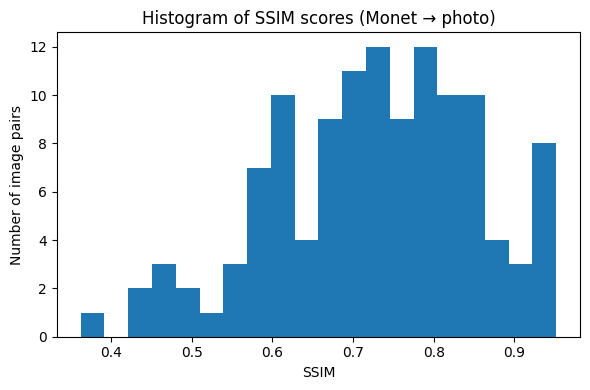


Selected examples:
Low   SSIM  (potentially too far from Monet) : index 115,  SSIM=0.362
Medium SSIM  (ideal?) : index 46, SSIM=0.731
High  SSIM  (too similar to Monet): index 5, SSIM=0.952


In [32]:
import matplotlib.pyplot as plt
from skimage.io import imread

# ssim_scores is currently a Python list -> convert to NumPy array
ssim_scores = np.array(ssim_scores)
mean_ssim = ssim_scores.mean()
std_ssim = ssim_scores.std()
min_ssim = ssim_scores.min()
max_ssim = ssim_scores.max()

print(f"Mean SSIM: {mean_ssim:.3f}")
print(f"Std  SSIM: {std_ssim:.3f}")
print(f"Min  SSIM: {min_ssim:.3f}")
print(f"Max  SSIM: {max_ssim:.3f}")

# Histogram of SSIM scores
plt.figure(figsize=(6, 4))
plt.hist(ssim_scores, bins=20)
plt.xlabel("SSIM")
plt.ylabel("Number of image pairs")
plt.title("Histogram of SSIM scores (Monet → photo)")
plt.tight_layout()
plt.show()

# Find examples of high, medium, low
sorted_idx = np.argsort(ssim_scores)  

low_idx   = sorted_idx[0]                     # lowest SSIM  → potential failure case (too different from Monet)
high_idx  = sorted_idx[-1]                    # highest SSIM → very Monet-like
mid_idx   = sorted_idx[len(sorted_idx) // 2]  # median SSIM → "ideal" zone? tbd

print("\nSelected examples:")
print(f"Low   SSIM  (potentially too far from Monet) : index {low_idx},  SSIM={ssim_scores[low_idx]:.3f}")
print(f"Medium SSIM  (ideal?) : index {mid_idx}, SSIM={ssim_scores[mid_idx]:.3f}")
print(f"High  SSIM  (too similar to Monet): index {high_idx}, SSIM={ssim_scores[high_idx]:.3f}")

Ranges are based on ChatGPT and examples in original paper. Assumptions must be double checked.

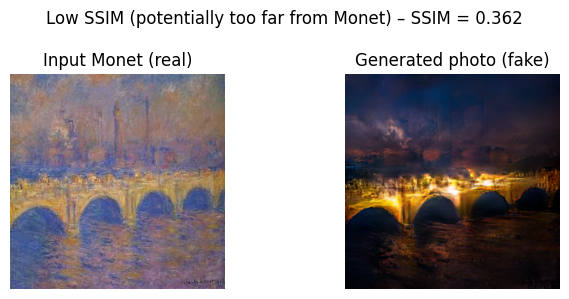

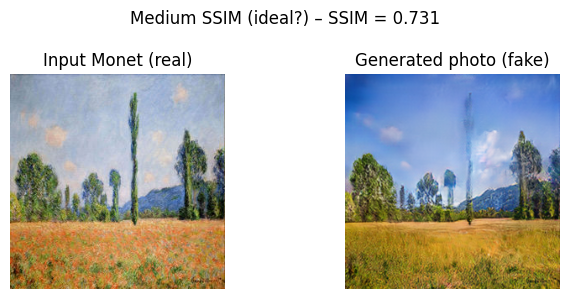

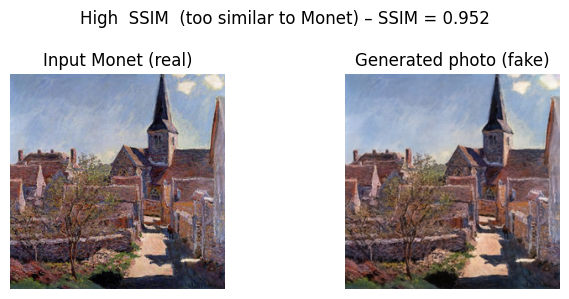

In [33]:
def show_pair(fake_path, real_path, title):
    fake_img = imread(fake_path)
    real_img = imread(real_path)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))

    axes[0].imshow(real_img)
    axes[0].set_title("Input Monet (real)")
    axes[0].axis("off")

    axes[1].imshow(fake_img)
    axes[1].set_title("Generated photo (fake)")
    axes[1].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_pair(
    *pairs[low_idx],
    title=f"Low SSIM (potentially too far from Monet) – SSIM = {ssim_scores[low_idx]:.3f}"
)

show_pair(
    *pairs[mid_idx],
    title=f"Medium SSIM (ideal?) – SSIM = {ssim_scores[mid_idx]:.3f}"
)

show_pair(
    *pairs[high_idx],
    title=f"High  SSIM  (too similar to Monet) – SSIM = {ssim_scores[high_idx]:.3f}"
)

Takeaway: the results of this SSIM analysis at least gives us initial insights into how much generated images differ from the original monet in the test dataset. It is also clear that we would like to decrease SSIM (it should for sure be not too high as that would mean little change compared to original Monet). We would have to investigate further where exactly we find the sweet spot for ideal SSIM (potentially also in combination with qualitative assessment). 

However, SSIM requires paired images and we are most interested in the similarity between generated photo and actual photos in our test set. Therefore, we have to turn to other metrics that do not require paired images. 

##### Embeddings, global mean difference & visualization

##### Inception V3

In [30]:
%pip install scikit-learn

  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 23.3 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [34]:
from PIL import Image

import torch
from torch import nn
import torchvision.transforms as T
import torchvision.models as models

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [35]:
base_dir = "/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix"

# generated Monet→photo outputs
fake_dir   = os.path.join(base_dir, "results/monet2photo_pretrained/test_monet_latest/images")

# training Monet paintings (A = 1,072 Monets)
monet_dir  = os.path.join(base_dir, "datasets/monet2photo/trainA")

# training real photos (B = 6,287 photos)
photo_dir  = os.path.join(base_dir, "datasets/monet2photo/trainB")

print(fake_dir)
print(monet_dir)
print(photo_dir)

/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/results/monet2photo_pretrained/test_monet_latest/images
/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/datasets/monet2photo/trainA
/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/datasets/monet2photo/trainB


In [36]:
# load pretrained inception v3 and remove classification head
inception = models.inception_v3(
    weights=models.Inception_V3_Weights.IMAGENET1K_V1
    # don't pass aux_logits here
)
inception.fc = nn.Identity()        # now output is 2048-d embedding
inception.eval().to(device)

# transform to what Inception expects: 299x299, normalized
inception_transform = T.Compose([
    T.Resize(299),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


In [37]:
def get_embeddings(image_paths, model, transform, device, batch_size=8):
    all_embs = []
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            img = Image.open(p).convert("RGB")
            imgs.append(transform(img))
        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            feats = model(imgs)

        all_embs.append(feats.cpu().numpy())
    return np.concatenate(all_embs, axis=0)


In [39]:
fake_paths = sorted(glob(os.path.join(fake_dir, "*_fake.png")))
monet_paths = sorted(glob(os.path.join(monet_dir, "*.jpg")))
photo_paths = sorted(glob(os.path.join(photo_dir, "*.jpg")))


In [41]:
print(f"\nExample fake path: {fake_paths[0]}")
print(f"Example Monet path: {monet_paths[0]}")
print(f"Example photo path: {photo_paths[0]}")


Example fake path: /Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/results/monet2photo_pretrained/test_monet_latest/images/00010_fake.png
Example Monet path: /Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/datasets/monet2photo/trainA/00001.jpg
Example photo path: /Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/datasets/monet2photo/trainB/2013-11-08 16:45:24.jpg


Getting inception embeddings for entire training monet images, training photos and generated images from GAN

In [42]:
fake_embs  = get_embeddings(fake_paths,inception, inception_transform, device)
monet_embs = get_embeddings(monet_paths,  inception, inception_transform, device)
photo_embs = get_embeddings(photo_paths,  inception, inception_transform, device)

print(fake_embs.shape, monet_embs.shape, photo_embs.shape)

(121, 2048) (1072, 2048) (6287, 2048)


In [43]:
mean_fake  = fake_embs.mean(axis=0)
mean_monet = monet_embs.mean(axis=0)
mean_photo = photo_embs.mean(axis=0)

dist_fake_monet = np.linalg.norm(mean_fake - mean_monet)
dist_fake_photo = np.linalg.norm(mean_fake - mean_photo)

print(f"L2 distance mean(fake)–mean(monet): {dist_fake_monet:.3f}")
print(f"L2 distance mean(fake)–mean(photo): {dist_fake_photo:.3f}")


L2 distance mean(fake)–mean(monet): 4.099
L2 distance mean(fake)–mean(photo): 2.970


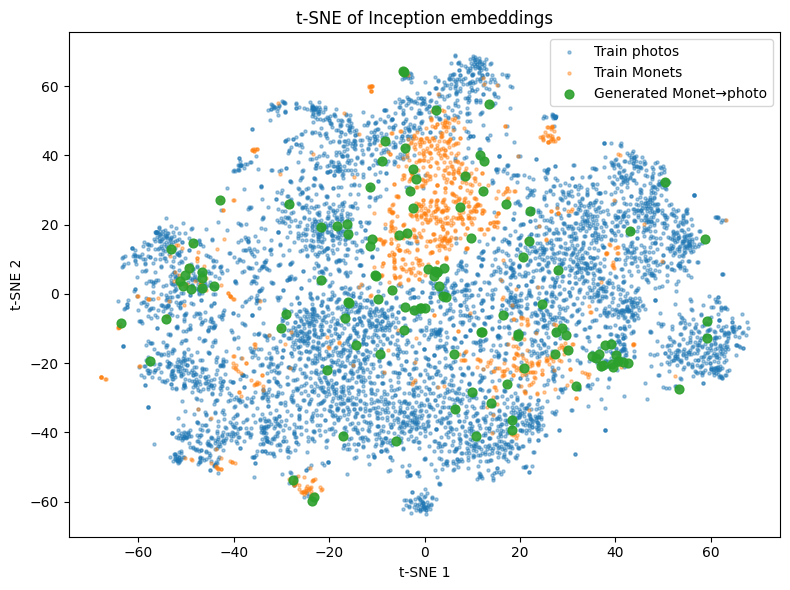

In [44]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X = np.vstack([photo_embs, fake_embs, monet_embs])
labels = (["real photo"] * len(photo_embs) +
          ["generated"]  * len(fake_embs)  +
          ["monet"]      * len(monet_embs))

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42,
)
X_2d = tsne.fit_transform(X)

labels_arr = np.array(labels)
mask_photo = labels_arr == "real photo"
mask_fake  = labels_arr == "generated"
mask_monet = labels_arr == "monet"

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[mask_photo, 0], X_2d[mask_photo, 1], s=5,  alpha=0.4, label="Train photos")
plt.scatter(X_2d[mask_monet, 0], X_2d[mask_monet, 1], s=5,  alpha=0.4, label="Train Monets")
plt.scatter(X_2d[mask_fake,  0], X_2d[mask_fake,  1], s=40, alpha=0.9, label="Generated Monet→photo")

plt.legend()
plt.title("t-SNE of Inception embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


##### CLIP

In [44]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached regex-2025.11.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (40 kB)
Using cached ftfy-6.3.1-py3-none-any.whl (44 kB)
Using cached regex-2025.11.3-cp312-cp312-macosx_11_0_arm64.whl (288 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ftfy]
  Cloning https://github.com/openai/CLIP.git to /private/var/folders/jq/byrm2rk92d994w903r7jtzmw0000gn/T/pip-req-build-j5kw3keo
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/jq/byrm2rk92d994w903r7jtzmw0000gn/T/pip-req-build-j5kw3keo
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=c62e341962d41dd4df94186c38546f21d38f6b46e585d17ed2302d86df270b0e
  Sto

In [45]:
import clip

In [46]:
# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load CLIP model
print("Loading CLIP model...")
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
print("CLIP model loaded successfully")

Using device: cpu
Loading CLIP model...
CLIP model loaded successfully


In [47]:
print(f"Fake dir: {fake_dir}")
print(f"Monet dir: {monet_dir}")
print(f"Photo dir: {photo_dir}")


Fake dir: /Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/results/monet2photo_pretrained/test_monet_latest/images
Monet dir: /Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/datasets/monet2photo/trainA
Photo dir: /Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/datasets/monet2photo/trainB


In [48]:
# function to get clip embeddings
def get_clip_embeddings(image_paths, model, preprocess, device, batch_size=32):
    """
    Generate CLIP embeddings for a list of images
    
    Args:
        image_paths: List of image file paths
        model: CLIP model
        preprocess: CLIP preprocessing transform
        device: torch device
        batch_size: Number of images to process at once
        
    Returns:
        numpy array of shape (n_images, 512) for ViT-B/32
    """
    all_embs = []
    
    print(f"Generating embeddings for {len(image_paths)} images...")
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        imgs = []
        
        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB")
                imgs.append(preprocess(img))
            except Exception as e:
                print(f"Error loading {p}: {e}")
                continue
        
        if not imgs:
            continue
            
        # Stack and move to device
        imgs = torch.stack(imgs).to(device)
        
        # Generate embeddings
        with torch.no_grad():
            feats = model.encode_image(imgs)
            # Normalize embeddings (this is standard practice with CLIP)
            feats = feats / feats.norm(dim=-1, keepdim=True)
        
        all_embs.append(feats.cpu().numpy())
        
        if (i // batch_size + 1) % 10 == 0:
            print(f"  Processed {i + len(batch_paths)}/{len(image_paths)} images")
    
    return np.concatenate(all_embs, axis=0)

In [49]:
# Generate CLIP embeddings for all three datasets
print("\n=== Generating CLIP Embeddings ===")
fake_embs = get_clip_embeddings(fake_paths, model, preprocess, device)
monet_embs = get_clip_embeddings(monet_paths, model, preprocess, device)
photo_embs = get_clip_embeddings(photo_paths, model, preprocess, device)

print(f"\nEmbedding shapes:")
print(f"  fake:  {fake_embs.shape}")
print(f"  monet: {monet_embs.shape}")
print(f"  photo: {photo_embs.shape}")


=== Generating CLIP Embeddings ===
Generating embeddings for 121 images...
Generating embeddings for 1072 images...
  Processed 320/1072 images
  Processed 640/1072 images
  Processed 960/1072 images
Generating embeddings for 6287 images...
  Processed 320/6287 images
  Processed 640/6287 images
  Processed 960/6287 images
  Processed 1280/6287 images
  Processed 1600/6287 images
  Processed 1920/6287 images
  Processed 2240/6287 images
  Processed 2560/6287 images
  Processed 2880/6287 images
  Processed 3200/6287 images
  Processed 3520/6287 images
  Processed 3840/6287 images
  Processed 4160/6287 images
  Processed 4480/6287 images
  Processed 4800/6287 images
  Processed 5120/6287 images
  Processed 5440/6287 images
  Processed 5760/6287 images
  Processed 6080/6287 images

Embedding shapes:
  fake:  (121, 512)
  monet: (1072, 512)
  photo: (6287, 512)


In [50]:
mean_fake = fake_embs.mean(axis=0)
mean_monet = monet_embs.mean(axis=0)
mean_photo = photo_embs.mean(axis=0)

dist_fake_monet = np.linalg.norm(mean_fake - mean_monet)
dist_fake_photo = np.linalg.norm(mean_fake - mean_photo)

print(f"\n=== L2 Distances (CLIP embeddings) ===")
print(f"L2 distance mean(fake)–mean(monet): {dist_fake_monet:.3f}")
print(f"L2 distance mean(fake)–mean(photo): {dist_fake_photo:.3f}")


=== L2 Distances (CLIP embeddings) ===
L2 distance mean(fake)–mean(monet): 0.508
L2 distance mean(fake)–mean(photo): 0.338


In [51]:
from sklearn.metrics.pairwise import cosine_similarity

cos_fake_monet = cosine_similarity(fake_embs, monet_embs).mean()
cos_fake_photo = cosine_similarity(fake_embs, photo_embs).mean()
cos_monet_photo = cosine_similarity(monet_embs, photo_embs).mean()

print(f"\n=== Cosine Similarities (CLIP embeddings) ===")
print(f"Mean cosine similarity fake–monet: {cos_fake_monet:.4f}")
print(f"Mean cosine similarity fake–photo: {cos_fake_photo:.4f}")
print(f"Mean cosine similarity monet–photo: {cos_monet_photo:.4f}")



=== Cosine Similarities (CLIP embeddings) ===
Mean cosine similarity fake–monet: 0.6069
Mean cosine similarity fake–photo: 0.6197
Mean cosine similarity monet–photo: 0.4939



=== Computing t-SNE ===
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 7480 samples in 0.001s...
[t-SNE] Computed neighbors for 7480 samples in 0.363s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7480
[t-SNE] Computed conditional probabilities for sample 2000 / 7480
[t-SNE] Computed conditional probabilities for sample 3000 / 7480
[t-SNE] Computed conditional probabilities for sample 4000 / 7480
[t-SNE] Computed conditional probabilities for sample 5000 / 7480
[t-SNE] Computed conditional probabilities for sample 6000 / 7480
[t-SNE] Computed conditional probabilities for sample 7000 / 7480
[t-SNE] Computed conditional probabilities for sample 7480 / 7480
[t-SNE] Mean sigma: 0.183128
[t-SNE] KL divergence after 250 iterations with early exaggeration: 87.088371
[t-SNE] KL divergence after 1000 iterations: 2.067065

Figure saved as 'tsne_clip_embeddings.png'


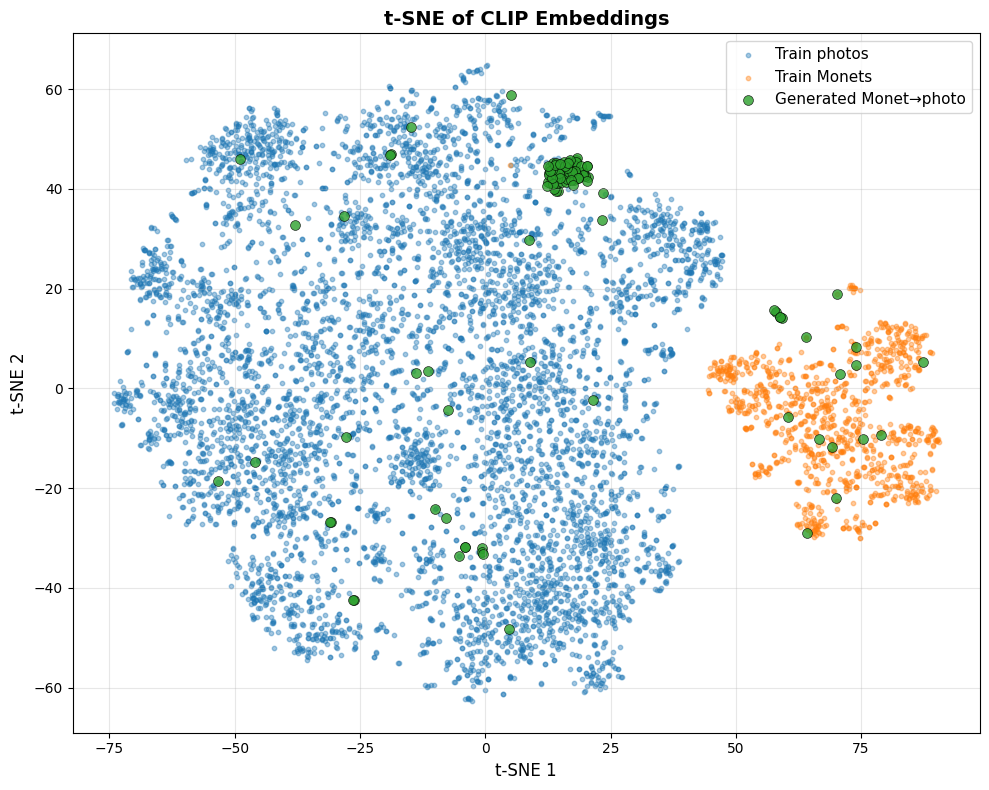

In [52]:
print("\n=== Computing t-SNE ===")
X = np.vstack([photo_embs, fake_embs, monet_embs])
labels = (["Train photos"] * len(photo_embs) +
          ["Generated Monet→photo"] * len(fake_embs) +
          ["Train Monets"] * len(monet_embs))

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42,
    verbose=1
)

X_2d = tsne.fit_transform(X)

# Create masks for each category
labels_arr = np.array(labels)
mask_photo = labels_arr == "Train photos"
mask_fake = labels_arr == "Generated Monet→photo"
mask_monet = labels_arr == "Train Monets"

# Plot t-SNE (matching your style)
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[mask_photo, 0], X_2d[mask_photo, 1], 
           s=10, alpha=0.4, label="Train photos", c='#1f77b4')
plt.scatter(X_2d[mask_monet, 0], X_2d[mask_monet, 1], 
           s=10, alpha=0.4, label="Train Monets", c='#ff7f0e')
plt.scatter(X_2d[mask_fake, 0], X_2d[mask_fake, 1], 
           s=50, alpha=0.8, label="Generated Monet→photo", 
           c='#2ca02c', edgecolors='black', linewidths=0.5)

plt.legend(fontsize=11, loc='upper right')
plt.title("t-SNE of CLIP Embeddings", fontsize=14, fontweight='bold')
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
print("\nFigure saved as 'tsne_clip_embeddings.png'")
plt.show()


=== SSIM Category Distribution ===
High SSIM (≥0.9): 9 images (7.4%)
Low SSIM (<0.6): 20 images (16.5%)
Medium SSIM (0.6-0.9): 92 images (76.0%)
  Mean SSIM in High SSIM (≥0.9): 0.936
  Mean SSIM in Low SSIM (<0.6): 0.526
  Mean SSIM in Medium SSIM (0.6-0.9): 0.748

Figure saved as 'tsne_clip_ssim_categories.png'


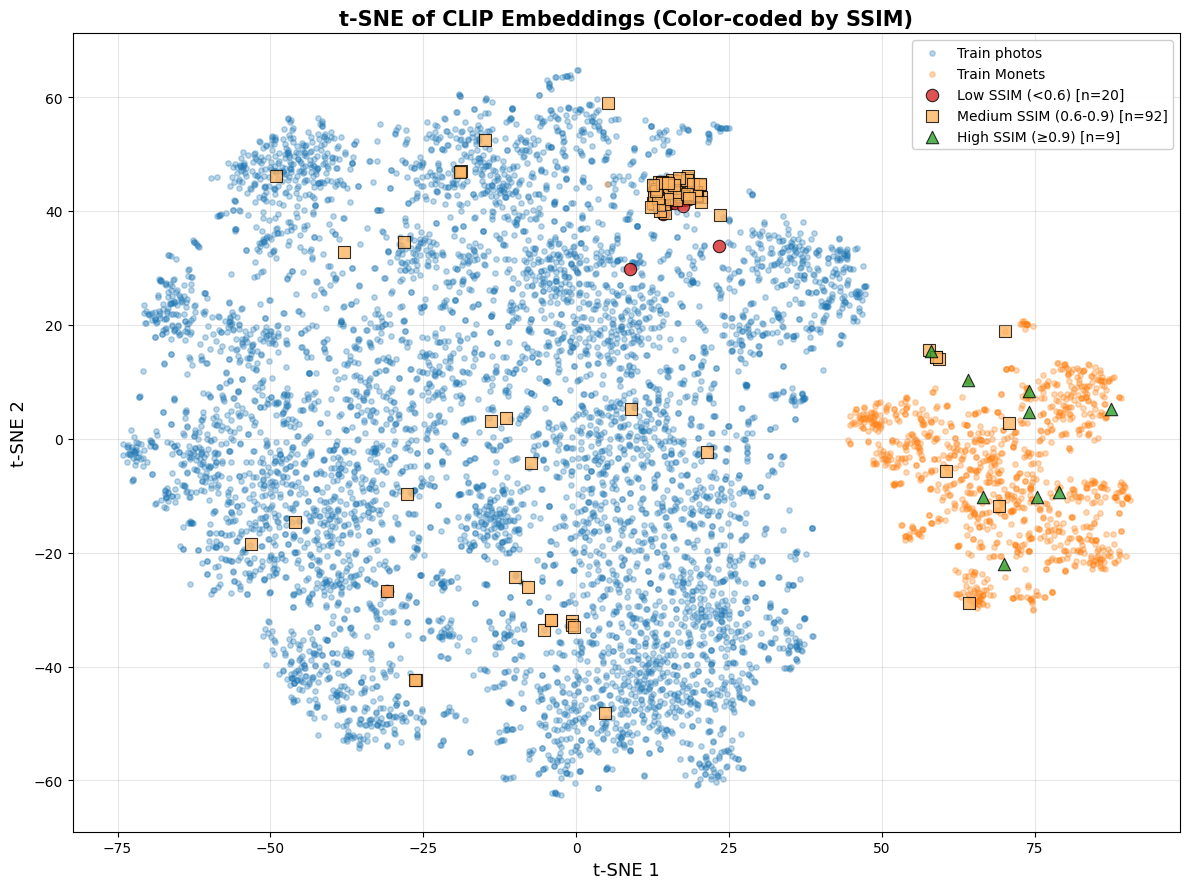


=== Analysis: SSIM Categories vs Distance to Photos ===

High SSIM (≥0.9):
  Mean distance to nearest photo in t-SNE: 31.01
  Std distance: 9.09
  Min distance: 12.93
  Max distance: 43.92

Low SSIM (<0.6):
  Mean distance to nearest photo in t-SNE: 1.56
  Std distance: 0.71
  Min distance: 0.44
  Max distance: 2.74

Medium SSIM (0.6-0.9):
  Mean distance to nearest photo in t-SNE: 3.84
  Std distance: 6.21
  Min distance: 0.04
  Max distance: 30.80

Figure saved as 'ssim_vs_distance_to_photos.png'


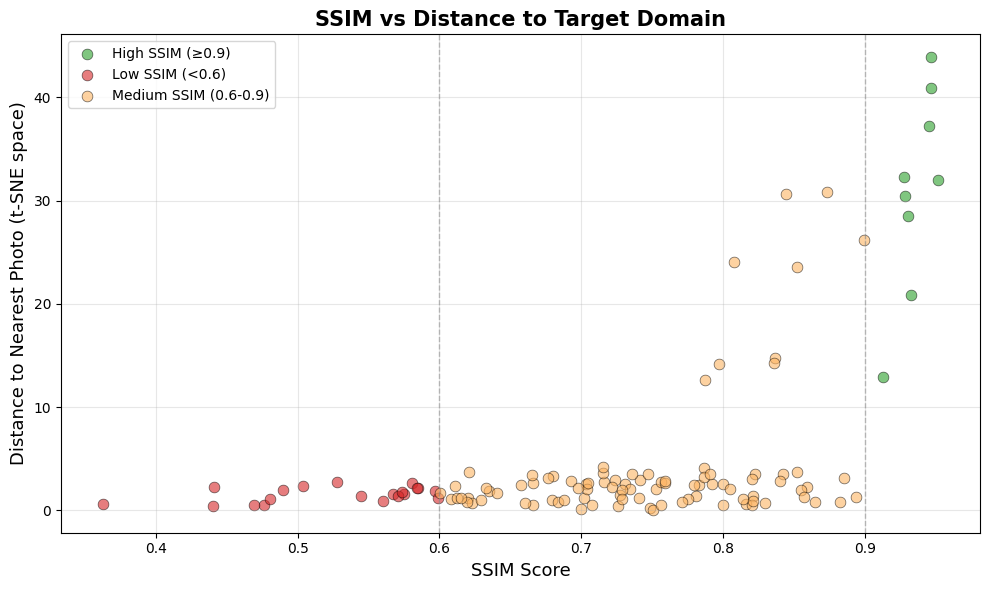

In [53]:
 #Categorize SSIM scores
def categorize_ssim(ssim_value):
    """Categorize SSIM score into Low, Medium, or High"""
    if ssim_value < 0.6:
        return "Low SSIM (<0.6)"
    elif ssim_value >= 0.9:
        return "High SSIM (≥0.9)"
    else:
        return "Medium SSIM (0.6-0.9)"

# Create SSIM categories for each fake image
ssim_categories = np.array([categorize_ssim(score) for score in ssim_scores])

# Count images in each category
unique_cats, counts = np.unique(ssim_categories, return_counts=True)
print("\n=== SSIM Category Distribution ===")
for cat, count in zip(unique_cats, counts):
    print(f"{cat}: {count} images ({count/len(ssim_scores)*100:.1f}%)")

# Calculate mean SSIM for each category
for cat in unique_cats:
    mask = ssim_categories == cat
    mean_ssim = ssim_scores[mask].mean()
    print(f"  Mean SSIM in {cat}: {mean_ssim:.3f}")


# Create masks for t-SNE coordinates
# Remember: X_2d = [photo_embs, fake_embs, monet_embs]
n_photo = len(photo_embs)
n_fake = len(fake_embs)
n_monet = len(monet_embs)

# Indices in X_2d
photo_start = 0
photo_end = n_photo
fake_start = n_photo
fake_end = n_photo + n_fake
monet_start = n_photo + n_fake
monet_end = n_photo + n_fake + n_monet

# Extract coordinates for each group
photo_coords = X_2d[photo_start:photo_end]
fake_coords = X_2d[fake_start:fake_end]
monet_coords = X_2d[monet_start:monet_end]

# Create SSIM-based masks for fake images
mask_low_ssim = ssim_categories == "Low SSIM (<0.6)"
mask_med_ssim = ssim_categories == "Medium SSIM (0.6-0.9)"
mask_high_ssim = ssim_categories == "High SSIM (≥0.9)"


# ==========================================
# Plot 1: t-SNE with SSIM categories
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

# Plot training data (background)
ax.scatter(photo_coords[:, 0], photo_coords[:, 1], 
          s=15, alpha=0.3, c='#1f77b4', label="Train photos")
ax.scatter(monet_coords[:, 0], monet_coords[:, 1], 
          s=15, alpha=0.3, c='#ff7f0e', label="Train Monets")

# Plot generated images by SSIM category
# Low SSIM - Red (potentially poor translation)
if mask_low_ssim.any():
    ax.scatter(fake_coords[mask_low_ssim, 0], fake_coords[mask_low_ssim, 1],
              s=80, alpha=0.8, c='#d62728', edgecolors='black', linewidths=0.8,
              marker='o', label=f"Low SSIM (<0.6) [n={mask_low_ssim.sum()}]")

# Medium SSIM - Yellow/Gold (good translation)
if mask_med_ssim.any():
    ax.scatter(fake_coords[mask_med_ssim, 0], fake_coords[mask_med_ssim, 1],
              s=80, alpha=0.8, c='#FDB462', edgecolors='black', linewidths=0.8,
              marker='s', label=f"Medium SSIM (0.6-0.9) [n={mask_med_ssim.sum()}]")

# High SSIM - Green (very similar to input, maybe too similar?)
if mask_high_ssim.any():
    ax.scatter(fake_coords[mask_high_ssim, 0], fake_coords[mask_high_ssim, 1],
              s=80, alpha=0.8, c='#2ca02c', edgecolors='black', linewidths=0.8,
              marker='^', label=f"High SSIM (≥0.9) [n={mask_high_ssim.sum()}]")

ax.set_xlabel("t-SNE 1", fontsize=13)
ax.set_ylabel("t-SNE 2", fontsize=13)
ax.set_title("t-SNE of CLIP Embeddings (Color-coded by SSIM)", fontsize=15, fontweight='bold')
ax.legend(fontsize=10, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tsne_clip_ssim_categories.png", dpi=300, bbox_inches='tight')
print("\nFigure saved as 'tsne_clip_ssim_categories.png'")
plt.show()


# ==========================================
# Analysis: Distance to target domain
# ==========================================
print("\n=== Analysis: SSIM Categories vs Distance to Photos ===")

# Calculate mean distance from each SSIM category to photo cluster
from scipy.spatial.distance import cdist

# Compute pairwise distances between fake images and photos in t-SNE space
distances_to_photos = cdist(fake_coords, photo_coords, metric='euclidean')
mean_dist_to_photos = distances_to_photos.min(axis=1)  # Distance to nearest photo

# Analyze by SSIM category
for cat in unique_cats:
    mask = ssim_categories == cat
    if mask.any():
        cat_distances = mean_dist_to_photos[mask]
        print(f"\n{cat}:")
        print(f"  Mean distance to nearest photo in t-SNE: {cat_distances.mean():.2f}")
        print(f"  Std distance: {cat_distances.std():.2f}")
        print(f"  Min distance: {cat_distances.min():.2f}")
        print(f"  Max distance: {cat_distances.max():.2f}")


# ==========================================
# Plot 2: SSIM vs Distance to Photos
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Scatter plot
colors_map = {
    "Low SSIM (<0.6)": '#d62728',
    "Medium SSIM (0.6-0.9)": '#FDB462',
    "High SSIM (≥0.9)": '#2ca02c'
}

for cat in unique_cats:
    mask = ssim_categories == cat
    if mask.any():
        ax.scatter(ssim_scores[mask], mean_dist_to_photos[mask], 
                  s=60, alpha=0.6, c=colors_map[cat], label=cat, edgecolors='black', linewidths=0.5)

ax.axvline(x=0.6, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel("SSIM Score", fontsize=13)
ax.set_ylabel("Distance to Nearest Photo (t-SNE space)", fontsize=13)
ax.set_title("SSIM vs Distance to Target Domain", fontsize=15, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Takeaways for now: 
1. Inception V3 embeddings give different results than CLIP (based on visualization)
2. SSIM measure somewhat aligns with clusters of CLIP (the higher the SSIM score, the closer it is in the clustering of Monet images in CLIP embeddings)

##### Cezanne in CLIP t-SNE Visualization

In [55]:
base_dir = "/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix"
os.chdir(base_dir)

Generating Cézanne→Photo translations using Monet2Photo model


In [56]:
!python test.py \
    --dataroot datasets/cezanne2photo/testA \
    --name monet2photo_pretrained \
    --model test \
    --no_dropout \
    --num_test 58 \
    --phase test_cezanne

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/cezanne2photo/testA  	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [57]:
# Define paths
cezanne_train_dir = os.path.join(base_dir, "datasets/cezanne2photo/trainA")
cezanne_test_dir = os.path.join(base_dir, "datasets/cezanne2photo/testA")
cezanne_generated_dir = os.path.join(base_dir, "results/monet2photo_pretrained/test_cezanne_latest/images")

# Also load original Monet and Photo training data for comparison
monet_train_dir = os.path.join(base_dir, "datasets/monet2photo/trainA")
photo_train_dir = os.path.join(base_dir, "datasets/monet2photo/trainB")

print("\n" + "=" * 60)
print("Loading image paths")
print("=" * 60)

# Gather paths
cezanne_train_paths = sorted(glob(os.path.join(cezanne_train_dir, "*.jpg")))
cezanne_generated_paths = sorted(glob(os.path.join(cezanne_generated_dir, "*_fake.png")))
monet_train_paths = sorted(glob(os.path.join(monet_train_dir, "*.jpg")))
photo_train_paths = sorted(glob(os.path.join(photo_train_dir, "*.jpg")))

print(f"Cézanne training images: {len(cezanne_train_paths)}")
print(f"Cézanne generated (fake) images: {len(cezanne_generated_paths)}")
print(f"Monet training images: {len(monet_train_paths)}")
print(f"Photo training images: {len(photo_train_paths)}")


Loading image paths
Cézanne training images: 525
Cézanne generated (fake) images: 58
Monet training images: 1072
Photo training images: 6287


In [59]:
model_clip, preprocess_clip = clip.load("ViT-B/32", device=device)


In [61]:
print("\nGenerating CLIP embeddings for all datasets...")
cezanne_train_clip = get_clip_embeddings(cezanne_train_paths, model_clip, preprocess, device)
cezanne_gen_clip = get_clip_embeddings(cezanne_generated_paths, model_clip, preprocess, device)

print(f"\nCLIP embedding shapes:")
print(f"  Monet: {monet_embs.shape}")
print(f"  Photo: {photo_embs.shape}")
print(f"  Monet generated: {fake_embs.shape}")
print(f"  Cézanne train: {cezanne_train_clip.shape}")
print(f"  Cézanne generated: {cezanne_gen_clip.shape}")



Generating CLIP embeddings for all datasets...
Generating embeddings for 525 images...
  Processed 320/525 images
Generating embeddings for 58 images...

CLIP embedding shapes:
  Monet: (1072, 512)
  Photo: (6287, 512)
  Monet generated: (121, 512)
  Cézanne train: (525, 512)
  Cézanne generated: (58, 512)


In [67]:
# Combine all CLIP embeddings
X_clip = np.vstack([photo_embs, monet_embs, cezanne_train_clip, cezanne_gen_clip, fake_embs])
labels_clip = (
    ["Real Photos"] * len(photo_embs) +
    ["Monet (train)"] * len(monet_embs) +
    ["Cézanne (train)"] * len(cezanne_train_clip) +
    ["Cézanne→Photo (generated)"] * len(cezanne_gen_clip) +
    ["Monet→Photo (generated)"] * len(fake_embs)
)

In [71]:
tsne_clip = TSNE(n_components=2, perplexity=30, learning_rate="auto", 
                 init="random", random_state=42, verbose=1)
X_2d_clip = tsne_clip.fit_transform(X_clip)

# Extract coordinates
n_photo = len(photo_embs)
n_monet = len(monet_embs)
n_cezanne_train = len(cezanne_train_clip)
n_cezanne_gen = len(cezanne_gen_clip)
n_monet_gen = len(fake_embs)

photo_coords_clip = X_2d_clip[:n_photo]
monet_coords_clip = X_2d_clip[n_photo:n_photo+n_monet]
cezanne_train_coords_clip = X_2d_clip[n_photo+n_monet:n_photo+n_monet+n_cezanne_train]
cezanne_gen_coords_clip = X_2d_clip[n_photo+n_monet+n_cezanne_train:n_photo+n_monet+n_cezanne_train+n_cezanne_gen]
monet_gen_coords_clip = X_2d_clip[n_photo+n_monet+n_cezanne_train+n_cezanne_gen:]

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 8063 samples in 0.001s...
[t-SNE] Computed neighbors for 8063 samples in 0.406s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8063
[t-SNE] Computed conditional probabilities for sample 2000 / 8063
[t-SNE] Computed conditional probabilities for sample 3000 / 8063
[t-SNE] Computed conditional probabilities for sample 4000 / 8063
[t-SNE] Computed conditional probabilities for sample 5000 / 8063
[t-SNE] Computed conditional probabilities for sample 6000 / 8063
[t-SNE] Computed conditional probabilities for sample 7000 / 8063
[t-SNE] Computed conditional probabilities for sample 8000 / 8063
[t-SNE] Computed conditional probabilities for sample 8063 / 8063
[t-SNE] Mean sigma: 0.183209
[t-SNE] KL divergence after 250 iterations with early exaggeration: 86.811859
[t-SNE] KL divergence after 1000 iterations: 2.024218



Creating CLIP visualization

CLIP figure saved as 'cezanne_transfer_clip.png'


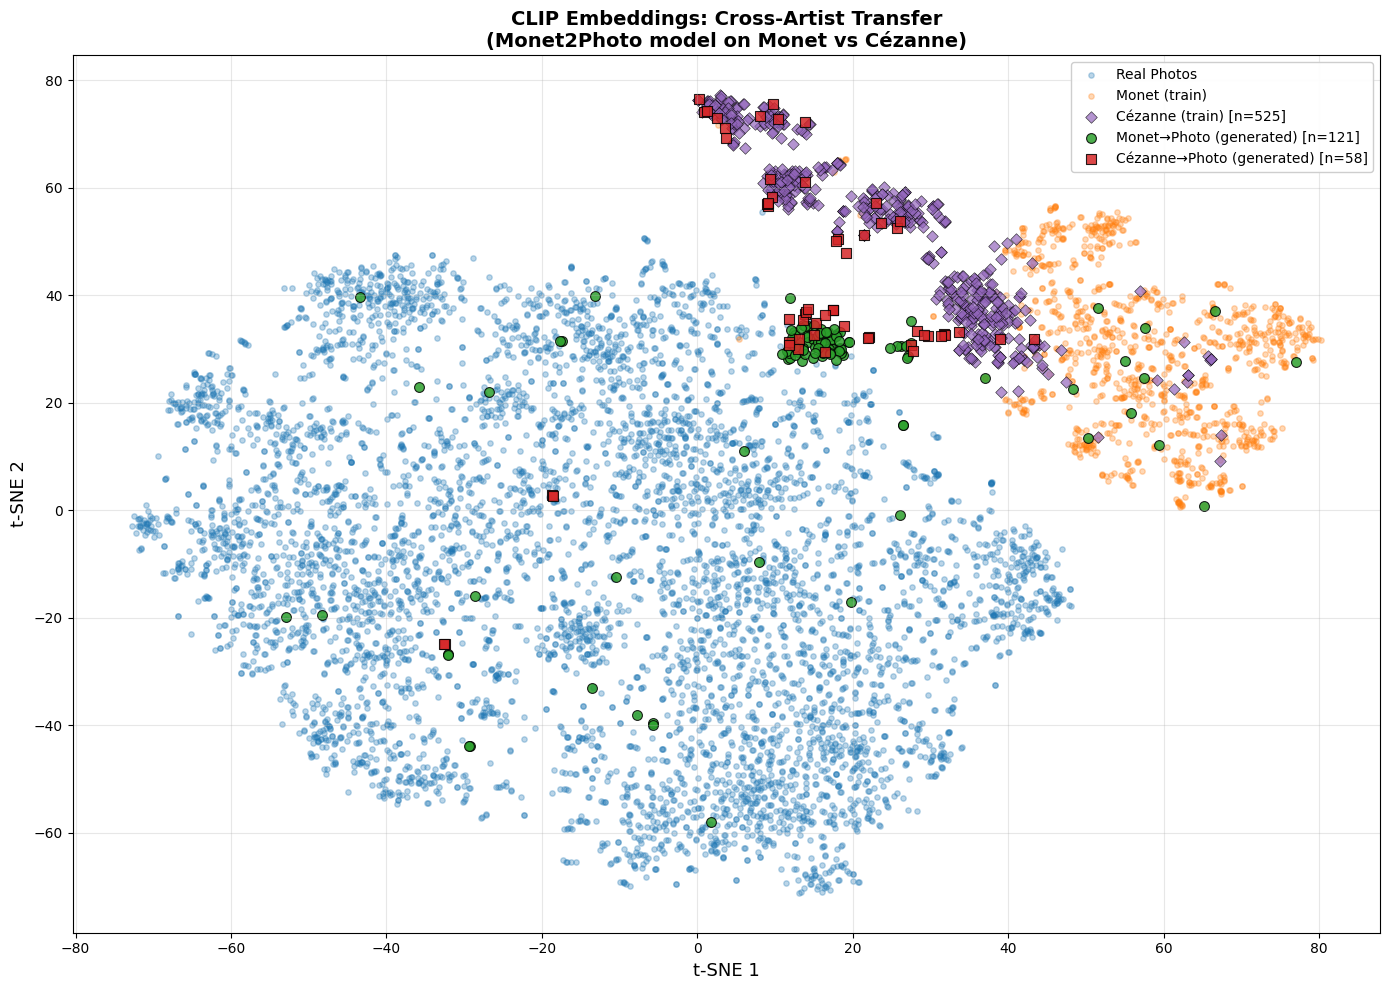

In [72]:
print("\n" + "=" * 60)
print("Creating CLIP visualization")
print("=" * 60)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot all groups
# Background: training data
ax.scatter(photo_coords_clip[:, 0], photo_coords_clip[:, 1],
          s=15, alpha=0.3, c='#1f77b4', label="Real Photos")
ax.scatter(monet_coords_clip[:, 0], monet_coords_clip[:, 1],
          s=15, alpha=0.3, c='#ff7f0e', label="Monet (train)")

# Foreground: Cézanne data
ax.scatter(cezanne_train_coords_clip[:, 0], cezanne_train_coords_clip[:, 1],
          s=35, alpha=0.7, c='#9467bd', marker='D', edgecolors='black', linewidths=0.5,
          label=f"Cézanne (train) [n={n_cezanne_train}]")

# Generated images: larger and more prominent
ax.scatter(monet_gen_coords_clip[:, 0], monet_gen_coords_clip[:, 1],
          s=50, alpha=0.85, c='#2ca02c', marker='o', edgecolors='black', linewidths=0.8,
          label=f"Monet→Photo (generated) [n={n_monet_gen}]")
ax.scatter(cezanne_gen_coords_clip[:, 0], cezanne_gen_coords_clip[:, 1],
          s=50, alpha=0.85, c='#d62728', marker='s', edgecolors='black', linewidths=0.8,
          label=f"Cézanne→Photo (generated) [n={n_cezanne_gen}]")

ax.set_xlabel("t-SNE 1", fontsize=13)
ax.set_ylabel("t-SNE 2", fontsize=13)
ax.set_title("CLIP Embeddings: Cross-Artist Transfer\n(Monet2Photo model on Monet vs Cézanne)", 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cezanne_transfer_clip.png", dpi=300, bbox_inches='tight')
print("\nCLIP figure saved as 'cezanne_transfer_clip.png'")
plt.show()